In [1]:
import numpy as np
import hubbard

NELEC = (1, 1)
NSITE = 2
T     = 1
U     = 4

dm0 = np.zeros((2, NSITE, NSITE))
dm0[0, 0, 0] = 1.0        # spin up on site 0
dm0[1, 1, 1] = 1.0        # spin down on site 1  (antiferromagnetic guess)

h1, eri, mol, mf = hubbard.hubbard_mf(
    NSITE, T, U, NELEC, dm0=dm0, pbc=True, verbose=4)


Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-30-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu


******** <class 'pyscf.scf.uhf.UHF'> ********
method = UHF
initial guess = minao
damping factor = 0
level_shift factor = 0
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-12
SCF conv_tol_grad = None
SCF max_cycles = 200
direct_scf = True
direct_scf_tol = 1e-13
chkfile to save SCF result = /tmp/tmpiixszmtt
max_memory 4000 MB (current use 798 MB)
number electrons alpha = 1  beta = 1
Set gradient conv threshold to 1e-06
init E= 0
  alpha nocc = 1  HOMO = -0.23606797749979  LUMO = 4.23606797749979
  beta  nocc = 1  HOMO = -0.23606797749979  LUMO = 4.23606797749979
  HOMO = -0.2360679775  LUMO = 4.2360679775  gap/eV = 121.69302
cycle= 1 E= -0.494427190999916  delta_E= -0.494 

Overwritten attributes  get_hcore get_ovlp  of <class 'pyscf.scf.uhf.UHF'>


In [5]:
from pyscf import fci

dm0 = np.zeros((2, NSITE, NSITE))
dm0[0, 0, 0] = 1.0        # spin up on site 0
dm0[1, 1, 1] = 1.0        # spin down on site 1  (antiferromagnetic guess)

h1, eri, mol, mf = hubbard.hubbard_mf(NSITE, T, U, NELEC, dm0=dm0, pbc=True)
e_fci, ci = fci.direct_spin1.kernel(h1, eri, NSITE, NELEC)

print("E(UHF)            = %+.10f   <S^2> = %.4f" % (mf.e_tot, mf.spin_square()[0]))
print("E(FCI, pyscf)     = %+.10f" % e_fci)
print("E(analytic)       = %+.10f" % ((U - np.sqrt(U**2 + 16*T**2)) / 2))
print("correlation energy= %+.10f" % (e_fci - mf.e_tot))
print("\nUHF alpha orbital:", mf.mo_coeff[0][:, 0], "   beta orbital:", mf.mo_coeff[1][:, 0])
print("FCI CI coefficient = ", ci)

E(UHF)            = -0.5000000000   <S^2> = 0.7500
E(FCI, pyscf)     = -0.8284271247
E(analytic)       = -0.8284271247
correlation energy= -0.3284271247

UHF alpha orbital: [0.96592583 0.25881904]    beta orbital: [0.25881904 0.96592583]
FCI CI coefficient =  [[-0.27059805 -0.65328148]
 [-0.65328148 -0.27059805]]


In [6]:
import sys
import time
from dataclasses import dataclass, field
from functools import partial
from typing import Any, Optional, Sequence

import numpy as np

def setup_jax() -> None:
    """Configure jax for AFQMC (float64, CPU/GPU backend).  Safe to call twice."""
    import jax

    if not jax.config.jax_enable_x64:
        jax.config.update("jax_enable_x64", True)


setup_jax()

import jax.numpy as jnp                      # noqa: E402
from jax import jit, random                  # noqa: E402

from afqmc import fp_sampling, linalg_utils, prep, propagation, sampling  # noqa: E402
from afqmc.wavefunctions import wavefunctions_unrestricted as uwf         # noqa: E402

class propagator_uhf_gen(propagation.propagator_unrestricted):
    """
    Unrestricted phaseless propagator, plus a free-projection step that also works
    when one spin channel is empty.

    `afqmc`'s `propagate_free` divides by 2*nelec[sigma] when re-attaching the
    accumulated phase, which raises ZeroDivisionError for a fully polarised system.
    Multiplying every occupied column of both determinants by c gives a determinant
    factor c^(n_up) * c^(n_dn) = c^(N_e), so c = phase**(1/N_e) works in general.
    (It also fixes `exp(dt*h0_prop + e_estimate)` -> `exp(dt*(h0_prop + e_estimate))`;
    that factor is walker independent and cancels in the estimator, but it can
    overflow.)
    """

    @partial(jit, static_argnums=(0, 1))
    def propagate_free(self, trial, ham_data, prop_data, fields):
        n_tot = trial.nelec[0] + trial.nelec[1]

        shift_term = jnp.einsum("wg,g->w", fields, ham_data["mf_shifts"])
        constants = jnp.exp(-jnp.sqrt(self.dt) * shift_term) * jnp.exp(
            self.dt * (ham_data["h0_prop"] + prop_data["e_estimate"]))

        constants_abs = jnp.abs(constants)
        phase = constants / constants_abs

        prop_data["weights"] = prop_data["weights"] * constants_abs
        prop_data["walkers"] = self._apply_trotprop(ham_data, prop_data["walkers"], fields)

        c = phase ** (1.0 / n_tot)
        prop_data["walkers"] = self._multiply_constant(prop_data["walkers"], jnp.stack((c, c)))
        return prop_data
    
@dataclass
class HubbardSystem:
    """Everything the drivers need: Hamiltonian, trial, and their intermediates."""
    ham: Any
    ham_data: dict
    nchol: int
    trial: Any
    wave_data: dict
    h1: np.ndarray
    u: float
    nelec: tuple
    norb: int

    @property
    def trial_vector(self) -> np.ndarray:
        """Occupied alpha trial orbitals as a real numpy array (norb, nocc)."""
        return np.asarray(self.wave_data["mo_coeff"][0]).real

@dataclass
class Snapshot:
    """A frozen walker population, taken at the end of a block."""
    run: int                    # trajectory (FP) or run (CP) index
    tau: float
    walkers: np.ndarray         # alpha determinants, (n_walkers, norb, n_up)
    walkers_dn: np.ndarray      # beta  determinants, (n_walkers, norb, n_dn)
    weights: np.ndarray         # (n_walkers,)
    overlaps: np.ndarray        # <Psi_T|phi_w>, (n_walkers,)
    importance: bool            # True if importance sampled (needs 1/overlap de-weighting)
    log_norm: float = 0.0       # log of the renormalisation this trajectory has
                                # accumulated; the walker weights are relative, so
                                # this is what sets the scale of one snapshot
                                # against another (free projection only)


@dataclass
class QMCResult:
    """Block energies plus whatever walker snapshots were requested."""
    method: str
    tau: np.ndarray                       # (n_blocks,)
    energy: np.ndarray                    # (n_blocks,) averaged over runs
    error: np.ndarray                     # (n_blocks,) scatter between runs
    block_energies: np.ndarray            # (n_runs, n_blocks) raw
    block_weights: Optional[np.ndarray]   # (n_runs, n_blocks), free projection only
    snaps: list = field(default_factory=list)
    log_amplitude: Optional[np.ndarray] = None   # (n_traj, n_samples), free projection
    ess: Optional[np.ndarray] = None             # effective no. of trajectories vs tau
    tau_eq: float = 0.0
    n_killed: int = 0
    walltime: float = 0.0
    prop_data: Any = None

    # -- convenience ------------------------------------------------------------
    @property
    def n_runs(self) -> int:
        return self.block_energies.shape[0]

    def snap_taus(self) -> np.ndarray:
        return np.array(sorted({round(s.tau, 8) for s in self.snaps}))

    def snaps_at(self, tau: float, atol: float = 1e-6) -> list:
        return [s for s in self.snaps if abs(s.tau - tau) < atol]

    def plateau(self, tau_eq: Optional[float] = None, n_seg: int = 1):
        """
        Converged energy: mean and error from the scatter of the independent runs.

        Block energies inside one run are strongly autocorrelated, so the naive
        per-block standard error is several times too small; averaging whole runs
        (optionally split into `n_seg` long contiguous segments) avoids that.
        """
        tau_eq = self.tau_eq if tau_eq is None else tau_eq
        mask = self.tau > tau_eq
        if not mask.any():
            raise ValueError("no blocks with tau > %g" % tau_eq)
        segs = np.array_split(self.block_energies[:, mask], n_seg, axis=1)
        means = np.concatenate([s.mean(axis=1) for s in segs])
        err = means.std(ddof=1) / np.sqrt(means.size) if means.size > 1 else np.nan
        return float(means.mean()), float(err)


In [7]:
class propagator_uhf_gen(propagation.propagator_unrestricted):
    """
    Unrestricted phaseless propagator, plus a free-projection step that also works
    when one spin channel is empty.

    `afqmc`'s `propagate_free` divides by 2*nelec[sigma] when re-attaching the
    accumulated phase, which raises ZeroDivisionError for a fully polarised system.
    Multiplying every occupied column of both determinants by c gives a determinant
    factor c^(n_up) * c^(n_dn) = c^(N_e), so c = phase**(1/N_e) works in general.
    (It also fixes `exp(dt*h0_prop + e_estimate)` -> `exp(dt*(h0_prop + e_estimate))`;
    that factor is walker independent and cancels in the estimator, but it can
    overflow.)
    """

    @partial(jit, static_argnums=(0, 1))
    def propagate_free(self, trial, ham_data, prop_data, fields):
        n_tot = trial.nelec[0] + trial.nelec[1]

        shift_term = jnp.einsum("wg,g->w", fields, ham_data["mf_shifts"])
        constants = jnp.exp(-jnp.sqrt(self.dt) * shift_term) * jnp.exp(
            self.dt * (ham_data["h0_prop"] + prop_data["e_estimate"]))

        constants_abs = jnp.abs(constants)
        phase = constants / constants_abs

        prop_data["weights"] = prop_data["weights"] * constants_abs
        prop_data["walkers"] = self._apply_trotprop(ham_data, prop_data["walkers"], fields)

        c = phase ** (1.0 / n_tot)
        prop_data["walkers"] = self._multiply_constant(prop_data["walkers"], jnp.stack((c, c)))
        return prop_data


@dataclass
class fp_sampler_gen(fp_sampling.fp_sampler):
    """
    `fp_sampler` with two changes.

    1.  The N_e-column phase redistribution, so a fully polarised system works.

    2.  The per-step renormalisation `W <- n_walkers * W / sum(W)` is *recorded*
        rather than discarded.  That factor is the trajectory's accumulated
        amplitude: it cancels inside one block (the block energy is a ratio, and
        the factor is common to every walker), but it is exactly what weights one
        trajectory against another.  Dropping it biases every average over
        trajectories.  We keep the renormalisation -- without it the weights
        overflow -- and accumulate log(sum(W)/n_walkers) in `prop_data["log_norm"]`,
        so no information is lost.

    `sr_every` sets the stochastic-reconfiguration cadence in steps (1 = every
    step, as in `afqmc`; 0 = never).  SR conserves the total weight, so it does not
    interfere with the bookkeeping -- but reconfiguring every step forces every
    walker weight to the mean, which is strong population control and carries its
    own O(1/n_walkers) bias.
    """

    sr_every: int = 1

    def __hash__(self) -> int:
        # @dataclass regenerates __eq__ and drops __hash__; both must see sr_every
        # or jit will silently reuse a trace made for a different cadence.
        return hash(tuple(self.__dict__.values()))

    @partial(jit, static_argnums=(0, 4, 5))
    def _step_scan(self, prop_data, fields, ham_data, prop, trial, wave_data):
        prop_data = prop.propagate_free(trial, ham_data, prop_data, fields)

        prop_data["walkers"], norms = linalg_utils.qr_vmap_uhf(prop_data["walkers"])
        norms = norms[0] * norms[1]
        norms_abs = jnp.abs(norms)
        phase = norms / norms_abs

        n_walkers = int(prop_data["weights"].shape[0])
        prop_data["weights"] = prop_data["weights"] * norms_abs

        total = jnp.sum(prop_data["weights"])
        prop_data["log_norm"] = prop_data["log_norm"] + jnp.log(total / n_walkers)
        prop_data["weights"] = n_walkers * prop_data["weights"] / total

        n_tot = trial.nelec[0] + trial.nelec[1]
        c = phase ** (1.0 / n_tot)
        prop_data["walkers"] = prop._multiply_constant(prop_data["walkers"], jnp.stack((c, c)))

        prop_data["step"] = prop_data["step"] + 1
        if self.sr_every:
            do_sr = (prop_data["step"] % self.sr_every) == 0
            keep_w = [prop_data["walkers"][0], prop_data["walkers"][1]]
            keep_wt = prop_data["weights"]
            prop_data = prop.stochastic_reconfiguration_local(prop_data)
            prop_data["walkers"] = [jnp.where(do_sr, prop_data["walkers"][k], keep_w[k])
                                    for k in (0, 1)]
            prop_data["weights"] = jnp.where(do_sr, prop_data["weights"], keep_wt)
        return prop_data, fields

In [8]:
def _fp_estimate(log_amp, es, sign=None):
    """
    Free-projection mixed estimator, amplitude-weighted over trajectories.

        E(tau) = sum_i A_i(tau) e_i(tau) / sum_i A_i(tau)

    where A_i is trajectory i's unnormalised <Psi_T|exp(-tau H)|Phi_0> and e_i its
    block energy.  A_i spans many orders of magnitude, so it is carried as
    log|A_i| (+ a sign) and the ratio is formed after subtracting the largest
    exponent.

    log_amp, es, sign : (n_samples, n_traj).  Trajectories are the SECOND axis, so
    a running estimate over the first i+1 of them slices as `log_amp[:, :i+1]`.

    Returns (relative amplitude, energy, error, effective no. of trajectories).
    The error is a jackknife over trajectories: for a ratio of sums with unequal
    weights, `std(e)/sqrt(n)` is not the right error.
    """
    log_amp = np.atleast_2d(np.real(log_amp))
    es = np.atleast_2d(np.real(es))
    n_traj = log_amp.shape[1]
    sign = np.ones_like(log_amp) if sign is None else np.atleast_2d(np.real(sign))

    a = sign * np.exp(log_amp - log_amp.max(axis=1, keepdims=True))    # (n_samples, n_traj)
    num, den = (a * es).sum(1), a.sum(1)
    mean = num / den

    # amplitude relative to tau = 0, for display: how fast the projection decays
    amp = np.exp(log_amp - log_amp[0].max()).mean(axis=1)

    if n_traj > 1:
        jk = (num[:, None] - a * es) / (den[:, None] - a)              # leave one out
        err = np.sqrt((n_traj - 1) / n_traj
                      * ((jk - jk.mean(axis=1, keepdims=True)) ** 2).sum(axis=1))
    else:
        err = np.full(mean.shape, np.nan)

    ess = np.abs(a).sum(1) ** 2 / (a ** 2).sum(1)                      # Kish
    return amp, mean, err, ess

In [9]:
def run_free_projection(system: HubbardSystem, *,
                        dt=0.0025, n_walkers=500, n_prop_steps=40, n_blocks=30,
                        n_traj=16, seed=0, n_exp_terms=10, sr_every=1,
                        snap_every=0, verbose=0) -> QMCResult:
    """
    Free-projection AFQMC: no force bias, no constraint, exact but with a variance
    that grows with tau.  The estimator is the mixed estimator with the trial
    overlap kept explicitly in the weight, averaged over independent trajectories.

    The returned arrays have n_blocks + 1 entries: entry 0 is the trial at tau = 0,
    entry b + 1 is block b, following afqmc/scripts/run_fpafqmc.py.

    Trajectories are combined by their accumulated amplitude
    A_i = <Psi_T|exp(-tau H)|Phi_0>_i, carried in logs, not by their block weight
    alone -- see `fp_sampler_gen` and `_fp_estimate`.

    sr_every   : stochastic-reconfiguration cadence in propagation steps.  1 (the
                 default, and what `afqmc` does) resets every walker weight to the
                 mean at every step: strong population control, small error bars,
                 an O(1/n_walkers) bias.  Larger values, or 0 for never, give a
                 truer free projection at the cost of a collapsing effective
                 sample size -- watch the ESS column.
    snap_every : store a walker snapshot every this many blocks, in every
                 trajectory (0 = none).  Also sets which tau rows get printed.
                 No snapshot is taken at tau = 0, where every walker is the trial.
    verbose    : 0 silent; 1 the running E(tau) table (throttled to every
                 n_traj // 10 trajectories); 2 also the reconstructed |Psi> at each
                 snapshot (one electron on two sites only).
    """
    prop = propagator_uhf_gen(dt=dt, n_walkers=n_walkers,
                              n_exp_terms=n_exp_terms, n_batch=1)
    hd = system.ham.build_propagation_intermediates(
        dict(system.ham_data), prop, system.trial, system.wave_data)
    smp = fp_sampler_gen(n_prop_steps=n_prop_steps, n_eql_blocks=n_blocks,
                         n_trj=n_traj, n_chol=system.nchol, sr_every=sr_every)

    # Sample 0 is the trial at tau = 0, as in afqmc/scripts/run_fpafqmc.py, so every
    # sample array has n_blocks + 1 rows and row b + 1 holds block b.
    tau = dt * n_prop_steps * np.arange(0, n_blocks + 1)
    row_every = snap_every if snap_every else max(1, n_blocks // 10)
    rows = list(range(0, n_blocks + 1, row_every))
    if rows[-1] != n_blocks:
        rows.append(n_blocks)
    traj_every = max(1, n_traj // 10)          # as in afqmc/scripts/run_fpafqmc.py
    analyse = verbose >= 2 and hubbard._can_analyse(system)
    t0 = time.time()

    # log|A| and sign(A) of each trajectory's <Psi_T|exp(-tau H)|Phi_0>, plus the
    # raw block weights and energies.  (n_samples, n_traj) throughout.
    log_amp = np.zeros((n_blocks + 1, n_traj))
    sgn = np.ones((n_blocks + 1, n_traj))
    ws = np.zeros((n_blocks + 1, n_traj))
    es = np.zeros((n_blocks + 1, n_traj))
    snaps, pd = [], None

    for i, key in enumerate(random.split(random.PRNGKey(seed), n_traj)):
        pd = prop.init_prop_data(system.trial, system.wave_data, hd, None)
        pd["key"] = key
        pd["log_norm"] = jnp.array(0.0)        # accumulated renormalisation, in logs
        pd["step"] = jnp.array(0)

        w0 = float(np.real(jnp.sum(pd["weights"] * pd["overlaps"])))
        ws[0, i] = w0
        es[0, i] = float(np.real(pd["e_estimate"]))
        log_amp[0, i] = np.log(abs(w0))
        sgn[0, i] = np.sign(w0)

        # A Python loop over `fp_block` rather than `scan_eql_blocks`: bit-identical
        # results for ~4% more time, and it keeps the intermediate walkers reachable
        # so that snap_every can work.
        for b in range(n_blocks):
            pd, (blk_w, blk_e) = smp.fp_block(pd, hd, prop, system.trial,
                                              system.wave_data)
            w = float(np.real(complex(blk_w)))
            ws[b + 1, i] = w
            es[b + 1, i] = float(np.real(complex(blk_e)))
            log_amp[b + 1, i] = float(pd["log_norm"]) + np.log(abs(w))
            sgn[b + 1, i] = np.sign(w)
            if snap_every and (b + 1) % snap_every == 0:
                snaps.append(hubbard._snapshot(pd, i, tau[b + 1], importance=False))

        if verbose and (i == 0 or (i + 1) % traj_every == 0 or i == n_traj - 1):
            amp_i, mean_i, err_i, ess_i = _fp_estimate(
                log_amp[:, :i + 1], es[:, :i + 1], sgn[:, :i + 1])
            print("\nFree projection | trajectories 1-%d of %d | %.1f s"
                  % (i + 1, n_traj, time.time() - t0))
            print("  %6s  %10s  %10s  %9s  %6s"
                  % ("tau", "amplitude", "Energy", "Error", "ESS"))
            for b in rows:
                e_str = "%9s" % "N/A" if np.isnan(err_i[b]) else "%9.5f" % err_i[b]
                print("  %6.2f  %10.3e  %10.5f  %s  %6.1f"
                      % (tau[b], amp_i[b], mean_i[b], e_str, ess_i[b]))
                if analyse and snap_every:
                    # running estimate over every trajectory finished so far, so
                    # this line matches the energy column above it
                    hit = [sn for sn in snaps if abs(sn.tau - tau[b]) < 1e-9]
                    if hit:
                        print(hubbard._snap_line(hit, system))

    amp, mean, err, ess = _fp_estimate(log_amp, es, sgn)

    if verbose:
        print("\n" + "=" * 68)
        print("  Free projection | %d trajectories x %d blocks | sr_every = %d | %.1f s"
              % (n_traj, n_blocks, sr_every, time.time() - t0))
        print("  E(tau = %.2f) = %+.5f +/- %.5f" % (tau[-1], mean[-1], err[-1]))
        print("  amplitude relative to tau = 0 : %.3e | effective trajectories: %.1f / %d"
              % (amp[-1], ess[-1], n_traj))
        if ess[-1] < 0.5 * n_traj:
            print("  WARNING: the trajectory amplitudes have spread out; the free")
            print("  projection is losing statistical power at this tau.")
        if analyse and snaps:
            tail = [sn for sn in snaps if sn.tau >= tau[-1] - 1e-9]
            if tail:
                print("  |Psi> at tau = %.2f :" % tail[0].tau)
                print(hubbard._snap_line(tail, system))
        print("=" * 68)

    return QMCResult(method="free projection", tau=tau,
                     energy=mean, error=err,
                     block_energies=es.T,               # (n_traj, n_samples)
                     block_weights=ws.T,
                     log_amplitude=log_amp.T, ess=ess,
                     snaps=snaps, tau_eq=0.0, n_killed=0,
                     walltime=time.time() - t0, prop_data=pd)

In [10]:
# mo_a = np.array([[1.0], [0.0]]) # electron pinned to site 0
# mo_b = np.array([[0.0], [1.0]])

mo_a = mf.mo_coeff[0][:,:NELEC[0]]
mo_b = mf.mo_coeff[1][:,:NELEC[1]]

qmc = hubbard.afqmc_setup(
    h1, U, NELEC, mo_a, mo_b, NSITE)

In [13]:
qmc_result = run_free_projection(
                qmc, dt=0.002, n_walkers=1000, 
                n_prop_steps=50, n_blocks=80,
                n_traj=1000, seed=0, n_exp_terms=10, sr_every=10,
                snap_every=10, verbose=4
                )


Free projection | trajectories 1-1 of 1000 | 5.0 s
     tau   amplitude      Energy      Error     ESS
    0.00   1.000e+00    -0.50000        N/A     1.0
    1.00   1.071e+00    -0.65086        N/A     1.0
    2.00   1.288e+00    -0.72488        N/A     1.0
    3.00   1.725e+00    -0.80163        N/A     1.0
    4.00   2.270e+00    -0.80468        N/A     1.0
    5.00   2.924e+00    -0.77799        N/A     1.0
    6.00   4.303e+00    -0.86476        N/A     1.0
    7.00   6.006e+00    -0.75597        N/A     1.0
    8.00   7.695e+00    -0.77841        N/A     1.0

Free projection | trajectories 1-100 of 1000 | 235.0 s
     tau   amplitude      Energy      Error     ESS
    0.00   1.000e+00    -0.50000    0.00000   100.0
    1.00   1.090e+00    -0.65379    0.00317    99.9
    2.00   1.348e+00    -0.75472    0.00511    99.5
    3.00   1.758e+00    -0.78490    0.00529    98.9
    4.00   2.369e+00    -0.80975    0.00631    98.1
    5.00   3.282e+00    -0.82784    0.00775    96.7
    6.00

In [2]:
def deterministic_estimator(H, v_trial, v_init, taus):
    r"""
    E_mix(tau) = <Psi_T| H e^{-tau H} |Phi_0> / <Psi_T| e^{-tau H} |Phi_0>
    -- the quantity AFQMC's mixed estimator converges to, evaluated exactly.
    """
    w, V = np.linalg.eigh(H)
    state = []
    energy = []
    for tau in taus:
        P = V @ np.diag(np.exp(-tau * w)) @ V.T
        v_tau = P @ v_init
        norm = np.sqrt(v_tau.T @ v_tau)
        v_tau = v_tau / norm
        state.append((v_tau))
        energy.append((v_trial @ H @ v_tau) / (v_trial @ v_tau))

    return np.array(state), np.array(energy)

In [ ]:
H_B, to_ci = hubbard.dimer_ci(T, U, NELEC)
v_T = to_ci(mf.mo_coeff[0][:, :1], mf.mo_coeff[1][:, :1])
state_det, energy_det = deterministic_estimator(H_B, v_T, v_T, qmc_result.tau)

In [ ]:
print(energy_det)
print(state_det)

In [46]:
print(e_fci)
print(ci)

-0.8284271247461863
[[-0.27059805 -0.65328148]
 [-0.65328148 -0.27059805]]


In [25]:
mo_a = mf.mo_coeff[0][:,:1]
mo_b = mf.mo_coeff[1][:,:1]
print(mo_a[0] * mo_b[0], mo_a[0] * mo_b[1], mo_a[1] * mo_b[0], mo_a[1] * mo_b[1])

[0.25] [0.9330127] [0.0669873] [0.25]


In [21]:
H_B

array([[ 4., -1., -1.,  0.],
       [-1.,  0.,  0., -1.],
       [-1.,  0.,  0., -1.],
       [ 0., -1., -1.,  4.]])

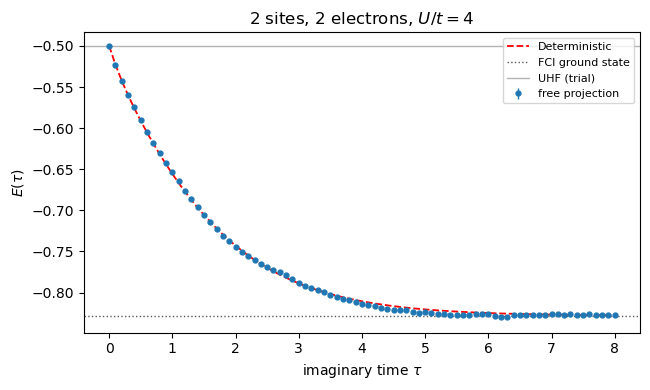

In [ ]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(qmc_result.tau, energy_det, "r--", lw=1.3, label=r"Deterministic")
ax.axhline(e_fci, color="0.35", lw=1.0, ls=":", label="FCI ground state")
ax.axhline(mf.e_tot, color="0.7", lw=1.0, ls="-", label="UHF (trial)")
ax.errorbar(qmc_result.tau, qmc_result.energy, qmc_result.error, fmt="o", ms=3.5, lw=1, label="free projection")
ax.set_xlabel(r"imaginary time $\tau$"); ax.set_ylabel(r"$E(\tau)$")
ax.set_title(r"2 sites, 2 electrons, $U/t=%g$" % (U / T))
ax.legend(fontsize=8, loc="upper right"); fig.tight_layout(); plt.show()

---

# Walker analysis: two electrons on two sites

With one electron in each spin channel a walker is a *pair* of orthonormalised
one-site orbitals, so it needs one angle per spin,

$$
|\phi_w\rangle=\big(\cos\alpha_w,\ \sin\alpha_w\big)_\uparrow
\;\otimes\;
\big(\cos\beta_w,\ \sin\beta_w\big)_\downarrow ,
$$

and its CI vector in the determinant basis
$\{|{\uparrow\downarrow},0\rangle,\ |{\uparrow},{\downarrow}\rangle,\ |{\downarrow},{\uparrow}\rangle,\ |0,{\uparrow\downarrow}\rangle\}$
(i.e. $|i_\uparrow j_\downarrow\rangle$ ordered $(0,0),(0,1),(1,0),(1,1)$) is the outer product

$$
\mathbf c_w=\big[\cos\alpha_w\cos\beta_w,\ \cos\alpha_w\sin\beta_w,\
\sin\alpha_w\cos\beta_w,\ \sin\alpha_w\sin\beta_w\big].
$$

The QMC wavefunction is the weighted sum of those,
$\mathbf c=\sum_w W_w\,\mathbf c_w$ for free projection
(and $\sum_w (W_w/\langle\Psi_T|\phi_w\rangle)\,\mathbf c_w$ for phaseless/CP).

### Why this case is qualitatively different from one electron

Every walker is a **product** state, so its CI vector always satisfies

$$
\Delta_w \;\equiv\; c_{00}c_{11}-c_{01}c_{10}
=\cos\alpha\cos\beta\,\sin\alpha\sin\beta-\cos\alpha\sin\beta\,\sin\alpha\cos\beta = 0 .
$$

The exact ground state does not: at $U/t=4$ it is
$\mathbf c=(0.2706,\,0.6533,\,0.6533,\,0.2706)$ with
$\Delta=-1/(2\sqrt2)=-0.35355$. So **no single walker can represent the answer** —
unlike the one-electron problem, where the target was a single point $\theta=\pi/4$
on the circle. Whatever correlation the QMC captures has to come from the *spread*
of the ensemble.

### The two angles are not independent — they are locked

For this model the propagator does something remarkable. Written out, the two spin
channels see

$$
\hat B_\uparrow=e^{-\frac{\Delta\tau}{2}h^{\rm mod}_\uparrow}\,
\mathrm{diag}\big(e^{+a x_0},e^{+a x_1}\big)\,e^{-\frac{\Delta\tau}{2}h^{\rm mod}_\uparrow},
\qquad
\hat B_\downarrow=\ \cdots\ \mathrm{diag}\big(e^{-a x_0},e^{-a x_1}\big)\ \cdots,
\qquad a=\sqrt{\Delta\tau\,U},
$$

*inverse* diagonals, because the spin decomposition puts $\mp i\sqrt U$ on the two
channels. The field step therefore maps
$\tan\alpha\to e^{a(x_1-x_0)}\tan\alpha$ and
$\tan\beta\to e^{-a(x_1-x_0)}\tan\beta$, leaving the product
$\tan\alpha\,\tan\beta$ **invariant**. And with the site-swap $S$, the one-body
factors obey $S\,h^{\rm mod}_\downarrow\,S=h^{\rm mod}_\uparrow$ whenever the trial
satisfies $C_\downarrow=S\,C_\uparrow$ — true of the Néel UHF solution, of the
site-localised guess, and of RHF.

So for those trials $\tan\alpha\tan\beta=1$, i.e.

$$\boxed{\ \beta_w=\tfrac{\pi}{2}-\alpha_w\ \ \text{for every walker, at every }\tau\ }$$

The joint distribution collapses onto the anti-diagonal, and the walker manifold is
effectively **one-dimensional**. On that line

$$c_{00}=c_{11}=\sin\alpha\cos\alpha,\qquad c_{01}=\cos^2\alpha,\qquad c_{10}=\sin^2\alpha,$$

and the ensemble defect becomes (with $\langle\cdot\rangle$ the weighted average)

$$
\Delta\;\propto\;\langle\sin\alpha\cos\alpha\rangle^{2}
-\langle\cos^{2}\alpha\rangle\langle\sin^{2}\alpha\rangle\;\le\;0
$$

by Cauchy–Schwarz, with equality **iff every walker has the same $\alpha$**. The
correlation energy of the Hubbard dimer is therefore, quite literally, the
*variance of $\alpha$* in the walker ensemble: a single determinant has none, and
the more the swarm spreads the more correlation it captures.

A trial that does not satisfy $C_\downarrow=S\,C_\uparrow$ breaks the lock, and the
distribution leaves that line; we run one below for contrast.

### Gauge

A determinant is a ray, and here the gauge group acts on both channels at once:
$(\uparrow,\downarrow)\to(-\uparrow,-\downarrow)$ leaves $\mathbf c_w$ unchanged, while
flipping a single channel flips the sign of $\mathbf c_w$. Since
`orthonormalize_walkers` throws away the sign that QR returns, the walkers come back
in whichever representative LAPACK picked; we map them to $\cos\alpha>0$ for plotting.

In [8]:
# ---------------------------------------------------------------------------
# Exact references in the determinant basis
# ---------------------------------------------------------------------------
import numpy as np
from matplotlib import pyplot as plt
import hubbard as hub

H_CI  = qmc.ci_hamiltonian          # 4x4 Hamiltonian in the determinant basis
V_T   = qmc.ci_trial                # the UHF trial written as a CI vector
w_ci, V_ci = np.linalg.eigh(H_CI)
C_EXACT = V_ci[:, 0] * np.sign(V_ci[:, 0] @ V_T)

LABELS = [r"$|\uparrow\downarrow,0\rangle$", r"$|\uparrow,\downarrow\rangle$",
          r"$|\downarrow,\uparrow\rangle$", r"$|0,\uparrow\downarrow\rangle$"]

def det_defect(c):
    "c00*c11 - c01*c10 : zero for any single Slater determinant."
    c = np.asarray(c)
    return c[..., 0] * c[..., 3] - c[..., 1] * c[..., 2]

def double_occ(c):
    "<n_up n_dn> summed over the two sites."
    c = np.asarray(c)
    return c[..., 0] ** 2 + c[..., 3] ** 2

def exact_state(tau):
    "e^{-tau H} |Phi_0> normalised -- what free projection's walkers represent."
    P = V_ci @ np.diag(np.exp(-tau * w_ci)) @ V_ci.T
    v = P @ V_T
    return v / np.linalg.norm(v)

print("H in the determinant basis:\n", H_CI)
print("\n%-22s %s" % ("trial (UHF) CI vector", np.round(V_T, 6)))
print("%-22s %s   E0 = %+.8f" % ("exact ground state", np.round(C_EXACT, 6), w_ci[0]))
print("\n%-22s trial %+.6f   exact %+.6f   (-1/(2 sqrt 2) = %+.6f)"
      % ("determinant defect", det_defect(V_T), det_defect(C_EXACT), -1 / (2 * np.sqrt(2))))
print("%-22s trial %+.6f   exact %+.6f"
      % ("double occupancy", double_occ(V_T), double_occ(C_EXACT)))
print("\nThe trial has zero defect because it IS a determinant; the exact state does not.")

H in the determinant basis:
 [[ 4. -1. -1.  0.]
 [-1.  0.  0. -1.]
 [-1.  0.  0. -1.]
 [ 0. -1. -1.  4.]]

trial (UHF) CI vector  [0.25     0.933013 0.066987 0.25    ]
exact ground state     [0.270598 0.653281 0.653281 0.270598]   E0 = -0.82842712

determinant defect     trial -0.000000   exact -0.353553   (-1/(2 sqrt 2) = -0.353553)
double occupancy       trial +0.125000   exact +0.146447

The trial has zero defect because it IS a determinant; the exact state does not.


In [9]:
# ---------------------------------------------------------------------------
# A free-projection run dedicated to the walker analysis: fewer trajectories than
# the energy run above, but walker snapshots every 10 blocks (every tau = 1).
# ---------------------------------------------------------------------------
import time
t0 = time.time()
walk = hub.run_free_projection(qmc, dt=0.002, n_walkers=500, n_prop_steps=50,
                               n_blocks=80, n_traj=60, seed=0, sr_every=10,
                               snap_every=10, verbose=0)
print("%.0f s | E(tau = %.1f) = %+.6f +/- %.6f  (FCI %+.6f)"
      % (time.time() - t0, walk.tau[-1], walk.energy[-1], walk.error[-1], w_ci[0]))
print("snapshots: %d, at tau = %s" % (len(walk.snaps), walk.snap_taus()))

127 s | E(tau = 8.0) = -0.823429 +/- 0.013987  (FCI -0.828427)
snapshots: 480, at tau = [1. 2. 3. 4. 5. 6. 7. 8.]


In [10]:
# ---------------------------------------------------------------------------
# Angles, gauge, and the product structure of every walker
# ---------------------------------------------------------------------------
alpha_raw = np.concatenate([hub.walker_angles(s)[0] for s in walk.snaps])
beta_raw  = np.concatenate([hub.walker_angles(s)[1] for s in walk.snaps])
ci_w      = np.concatenate([hub.ci_vectors(s) for s in walk.snaps])
wts       = np.concatenate([s.weights for s in walk.snaps])

alpha, beta = hub.gauge_fix(alpha_raw), hub.gauge_fix(beta_raw)

print("raw         alpha [%+.4f, %+.4f]   beta [%+.4f, %+.4f]"
      % (alpha_raw.min(), alpha_raw.max(), beta_raw.min(), beta_raw.max()))
print("gauge fixed alpha [%+.4f, %+.4f]   beta [%+.4f, %+.4f]   (pi/2 = %.4f)"
      % (alpha.min(), alpha.max(), beta.min(), beta.max(), np.pi / 2))
print("\nboth channels flipped together for %.1f%% of walkers"
      % (100 * np.mean((np.cos(alpha_raw) < 0) == (np.cos(beta_raw) < 0))))
print("  -> the flip is a gauge transformation and leaves the CI vector alone.")
print("  Both angles stay in [0, pi/2]: the propagator is a positive matrix in each")
print("  spin channel separately, so neither electron can cross a node.")
print("\nper-walker determinant defect: max |c00 c11 - c01 c10| = %.2e  (must vanish)"
      % np.abs(det_defect(ci_w)).max())

# --- are the two angles locked? ---------------------------------------------
print("\nlock  beta = pi/2 - alpha :  max |alpha + beta - pi/2| = %.2e"
      % np.abs(alpha + beta - np.pi / 2).max())
print("  (exact for any trial with C_dn = S C_up; the residual is the Taylor")
print("   truncation of exp(v_HS), not a statistical error)")

ca, sa = np.cos(alpha), np.sin(alpha)
wm = lambda x: np.average(x, weights=wts)
cs = wm(sa * ca) ** 2 - wm(ca ** 2) * wm(sa ** 2)
print("\n<sc>^2 - <c^2><s^2> = %+.6f   (<= 0 by Cauchy-Schwarz, = 0 iff all walkers"
      " share one alpha)" % cs)
print("weighted std of alpha = %.4f   ->  the spread IS the correlation" % np.sqrt(
    wm(alpha ** 2) - wm(alpha) ** 2))

raw         alpha [-3.1232, -1.5911]   beta [-3.1213, -1.5892]
gauge fixed alpha [+0.0184, +1.5505]   beta [+0.0203, +1.5524]   (pi/2 = 1.5708)

both channels flipped together for 100.0% of walkers
  -> the flip is a gauge transformation and leaves the CI vector alone.
  Both angles stay in [0, pi/2]: the propagator is a positive matrix in each
  spin channel separately, so neither electron can cross a node.

per-walker determinant defect: max |c00 c11 - c01 c10| = 8.33e-17  (must vanish)

lock  beta = pi/2 - alpha :  max |alpha + beta - pi/2| = 1.23e-10
  (exact for any trial with C_dn = S C_up; the residual is the Taylor
   truncation of exp(v_HS), not a statistical error)

<sc>^2 - <c^2><s^2> = -0.203846   (<= 0 by Cauchy-Schwarz, = 0 iff all walkers share one alpha)
weighted std of alpha = 0.5753   ->  the spread IS the correlation


In [11]:
# ---------------------------------------------------------------------------
# For contrast: a trial that breaks C_dn = S C_up, so the lock is lifted
# ---------------------------------------------------------------------------
qmc_asym = hub.afqmc_setup(h1, U, NELEC, np.array([[1.0], [0.0]]),
                           np.ones((2, 1)) / np.sqrt(2), NSITE)
walk_asym = hub.run_free_projection(qmc_asym, dt=0.002, n_walkers=500,
                                    n_prop_steps=50, n_blocks=40, n_traj=20,
                                    seed=1, sr_every=10, snap_every=10, verbose=0)
alpha_as = np.concatenate([hub.gauge_fix(hub.walker_angles(s)[0]) for s in walk_asym.snaps])
beta_as  = np.concatenate([hub.gauge_fix(hub.walker_angles(s)[1]) for s in walk_asym.snaps])
wts_as   = np.concatenate([s.weights for s in walk_asym.snaps])
print("symmetric trial   : max |alpha + beta - pi/2| = %.2e"
      % np.abs(alpha + beta - np.pi / 2).max())
print("asymmetric trial  : max |alpha + beta - pi/2| = %.2e   -> lock broken"
      % np.abs(alpha_as + beta_as - np.pi / 2).max())

symmetric trial   : max |alpha + beta - pi/2| = 1.23e-10
asymmetric trial  : max |alpha + beta - pi/2| = 1.60e-01   -> lock broken


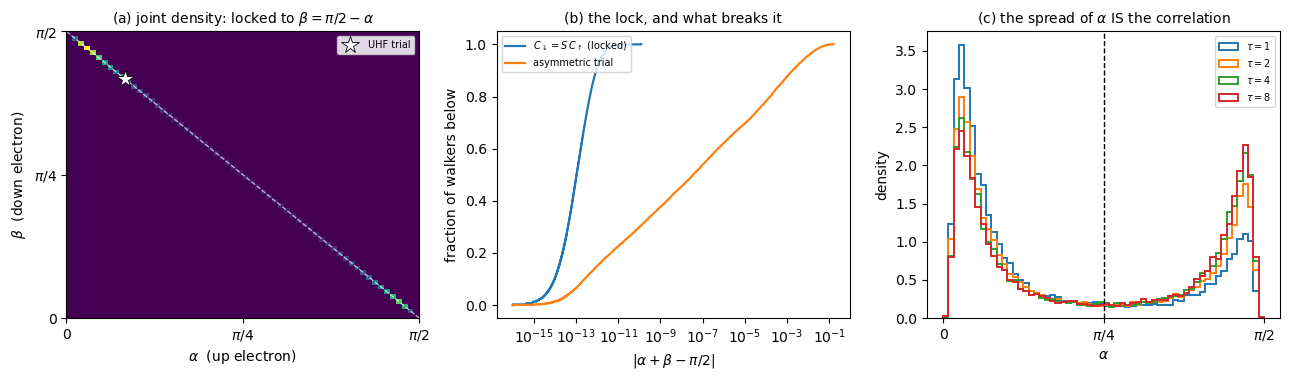

rms |alpha + beta - pi/2| :  locked 1.3e-12   asymmetric trial 0.0082
  tau= 1.0   std(alpha) = 0.5233   <sc>^2-<c^2><s^2> = -0.171568
  tau= 2.0   std(alpha) = 0.5654   <sc>^2-<c^2><s^2> = -0.197627
  tau= 4.0   std(alpha) = 0.5797   <sc>^2-<c^2><s^2> = -0.206419
  tau= 8.0   std(alpha) = 0.5797   <sc>^2-<c^2><s^2> = -0.206663


In [12]:
edges = np.linspace(0, np.pi / 2, 61)
ticks, tlabels = [0, np.pi / 4, np.pi / 2], ["0", r"$\pi/4$", r"$\pi/2$"]
tr_a = np.arctan2(*qmc.trial_vector.ravel()[::-1])
tr_b = np.arctan2(*np.asarray(qmc.wave_data["mo_coeff"][1]).real.ravel()[::-1])

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.9))

# (a) the joint density -- a line, not a cloud
ax = axes[0]
ax.hist2d(alpha, beta, bins=[edges, edges], weights=wts, cmap="viridis")
ax.plot(edges, np.pi / 2 - edges, "w--", lw=0.9, alpha=0.7)
ax.plot(tr_a, tr_b, "w*", ms=13, mec="k", mew=0.6, label="UHF trial")
ax.set_xlabel(r"$\alpha$  (up electron)"); ax.set_ylabel(r"$\beta$  (down electron)")
ax.set_xticks(ticks); ax.set_xticklabels(tlabels)
ax.set_yticks(ticks); ax.set_yticklabels(tlabels)
ax.set_title(r"(a) joint density: locked to $\beta=\pi/2-\alpha$", fontsize=10)
ax.legend(fontsize=7, loc="upper right", framealpha=0.85)

# (b) how exactly is it locked?  empirical CDF of |alpha + beta - pi/2|
ax = axes[1]
for d, w, col, lab in ((np.abs(alpha + beta - np.pi / 2), wts, "C0",
                        r"$C_\downarrow=S\,C_\uparrow$ (locked)"),
                       (np.abs(alpha_as + beta_as - np.pi / 2), wts_as, "C1",
                        "asymmetric trial")):
    o = np.argsort(d)
    cw = np.cumsum(w[o]) / w.sum()
    ax.step(np.maximum(d[o], 1e-16), cw, where="post", lw=1.6, color=col, label=lab)
ax.set_xscale("log")
ax.set_xlabel(r"$|\alpha+\beta-\pi/2|$")
ax.set_ylabel("fraction of walkers below")
ax.set_title("(b) the lock, and what breaks it", fontsize=10)
ax.legend(fontsize=7, loc="upper left")

# (c) the marginal of alpha, spreading with imaginary time
ax = axes[2]
for t in (1.0, 2.0, 4.0, 8.0):
    sn = walk.snaps_at(t)
    a_t = np.concatenate([hub.gauge_fix(hub.walker_angles(x)[0]) for x in sn])
    w_t = np.concatenate([x.weights for x in sn])
    ax.hist(a_t, bins=edges, weights=w_t, density=True, histtype="step", lw=1.4,
            label=r"$\tau=%.0f$" % t)
ax.axvline(np.pi / 4, color="k", ls="--", lw=1.0)
ax.set_xlabel(r"$\alpha$"); ax.set_ylabel("density")
ax.set_xticks(ticks); ax.set_xticklabels(tlabels)
ax.set_title(r"(c) the spread of $\alpha$ IS the correlation", fontsize=10)
ax.legend(fontsize=7)
fig.tight_layout(); plt.show()

print("rms |alpha + beta - pi/2| :  locked %.1e   asymmetric trial %.4f"
      % (np.sqrt(np.average((alpha + beta - np.pi / 2) ** 2, weights=wts)),
         np.sqrt(np.average((alpha_as + beta_as - np.pi / 2) ** 2, weights=wts_as))))
for t in (1.0, 2.0, 4.0, 8.0):
    sn = walk.snaps_at(t)
    a_t = np.concatenate([hub.gauge_fix(hub.walker_angles(x)[0]) for x in sn])
    w_t = np.concatenate([x.weights for x in sn])
    m = np.average(a_t, weights=w_t)
    sd = np.sqrt(np.average((a_t - m) ** 2, weights=w_t))
    c_ = np.cos(a_t); s_ = np.sin(a_t)
    wa = lambda x: np.average(x, weights=w_t)
    print("  tau=%4.1f   std(alpha) = %.4f   <sc>^2-<c^2><s^2> = %+.6f"
          % (t, sd, wa(s_ * c_) ** 2 - wa(c_ ** 2) * wa(s_ ** 2)))

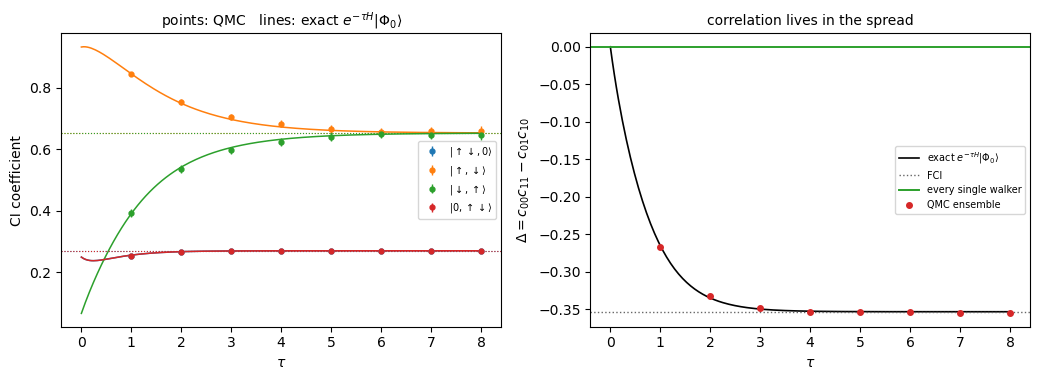

In [13]:
taus = walk.snap_taus()
recs = [hub.wavefunction(walk.snaps_at(t), H_CI, V_T) for t in taus]
rec = np.array([r["c"] for r in recs])
rec_e = np.array([r["c_err"] for r in recs])
tt = np.linspace(0, taus[-1], 200)
det = np.array([exact_state(t) for t in tt])

fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(10.5, 3.9))
for k in range(4):
    ax2.plot(tt, det[:, k], "-", lw=1.1, color="C%d" % k)
    ax2.errorbar(taus, rec[:, k], rec_e[:, k], fmt="o", ms=3.5, lw=1,
                 color="C%d" % k, label=LABELS[k])
    ax2.axhline(C_EXACT[k], color="C%d" % k, ls=":", lw=0.8)
ax2.set_xlabel(r"$\tau$"); ax2.set_ylabel("CI coefficient")
ax2.set_title(r"points: QMC   lines: exact $e^{-\tau H}|\Phi_0\rangle$", fontsize=10)
ax2.legend(fontsize=7, loc="center right")

ax3.plot(tt, det_defect(det), "k-", lw=1.2, label=r"exact $e^{-\tau H}|\Phi_0\rangle$")
ax3.errorbar(taus, det_defect(rec), fmt="o", ms=4, lw=1, color="C3", label="QMC ensemble")
ax3.axhline(det_defect(C_EXACT), color="0.4", ls=":", lw=1.0, label="FCI")
ax3.axhline(0.0, color="C2", lw=1.4, label="every single walker")
ax3.set_xlabel(r"$\tau$"); ax3.set_ylabel(r"$\Delta=c_{00}c_{11}-c_{01}c_{10}$")
ax3.set_title("correlation lives in the spread", fontsize=10)
ax3.legend(fontsize=7, loc="center right")
fig.tight_layout(); plt.show()

In [14]:
# ---------------------------------------------------------------------------
# The reconstructed CI vector against the deterministic propagation
# ---------------------------------------------------------------------------
print("            %s" % "  ".join("%9s" % s for s in
      ["c(ud,0)", "c(u,d)", "c(d,u)", "c(0,ud)", "defect", "double occ"]))
for t in taus[::2]:
    r = hub.wavefunction(walk.snaps_at(t), H_CI, V_T)
    ex = exact_state(t)
    print("  tau=%4.1f  %s   QMC  +/- %s"
          % (t, "  ".join("%+9.4f" % x for x in
                          list(r["c"]) + [det_defect(r["c"]), double_occ(r["c"])]),
             "  ".join("%.4f" % x for x in r["c_err"])))
    print("            %s   exact"
          % "  ".join("%+9.4f" % x for x in
                      list(ex) + [det_defect(ex), double_occ(ex)]))
print("  tau=inf   %s   FCI"
      % "  ".join("%+9.4f" % x for x in
                  list(C_EXACT) + [det_defect(C_EXACT), double_occ(C_EXACT)]))

r_last = hub.wavefunction(walk.snaps_at(taus[-1]), H_CI, V_T)
print("\nat tau = %.1f :" % taus[-1])
print("  E_var of the reconstructed state = %+.6f   (FCI %+.6f)"
      % (r_last["e_var"], w_ci[0]))
print("  E_mix of the reconstructed state = %+.6f   (sampler said %+.6f)"
      % (r_last["e_mix"], walk.energy[-1]))

              c(ud,0)     c(u,d)     c(d,u)    c(0,ud)     defect  double occ
  tau= 1.0    +0.2547    +0.8464    +0.3924    +0.2547    -0.2672    +0.1297   QMC  +/- 0.0013  0.0064  0.0129  0.0013
              +0.2564    +0.8457    +0.3915    +0.2564    -0.2653    +0.1315   exact
  tau= 3.0    +0.2705    +0.7045    +0.5979    +0.2705    -0.3480    +0.1463   QMC  +/- 0.0016  0.0094  0.0112  0.0016
              +0.2700    +0.6976    +0.6063    +0.2700    -0.3500    +0.1458   exact
  tau= 5.0    +0.2694    +0.6658    +0.6416    +0.2694    -0.3546    +0.1451   QMC  +/- 0.0015  0.0142  0.0153  0.0015
              +0.2706    +0.6620    +0.6445    +0.2706    -0.3534    +0.1464   exact
  tau= 7.0    +0.2692    +0.6609    +0.6467    +0.2692    -0.3549    +0.1450   QMC  +/- 0.0014  0.0121  0.0129  0.0014
              +0.2706    +0.6549    +0.6516    +0.2706    -0.3535    +0.1464   exact
  tau=inf     +0.2706    +0.6533    +0.6533    +0.2706    -0.3536    +0.1464   FCI

at tau = 8.0 :
  E_var

## What the two-electron walker distribution shows

* **Every walker is a product state**, with $\Delta_w=0$ to machine precision
  ($\sim10^{-16}$). The ensemble nevertheless reproduces the exact
  $\Delta=-0.354$: the correlation is carried entirely by the spread of the swarm,
  never by any individual walker. The right panel shows $\Delta$ growing from the
  trial's $0$ towards the FCI value, while the green line — every walker,
  individually — stays pinned at zero.

* **The two angles are locked**, $\beta=\pi/2-\alpha$ to $\sim10^{-11}$, for any
  trial with $C_\downarrow=S\,C_\uparrow$. The field step multiplies $\tan\alpha$ and
  $\tan\beta$ by reciprocal factors — that is the spin decomposition's
  $\mp i\sqrt U$ showing up in real space — and the one-body step commutes with the
  site swap. So the "two-dimensional" walker distribution is really
  one-dimensional here, and the second panel shows what it looks like once a trial
  breaks the lock.

* **The correlation energy is the variance of $\alpha$.** On the locked line,
  $\Delta\propto\langle sc\rangle^{2}-\langle c^{2}\rangle\langle s^{2}\rangle\le0$
  by Cauchy–Schwarz, with equality iff all walkers share one $\alpha$. A single
  determinant is the zero-variance limit; spreading the swarm is what buys the
  correlation.

* **Both angles stay in $[0,\pi/2]$.** The propagator is a positive matrix in each
  spin channel separately, so neither electron can cross a node — the
  two-electron version of the argument in the one-electron notebook. No sign
  problem, which is why free projection stays well behaved out to $\tau=8$.

* **The reconstructed CI vector tracks $e^{-\tau H}|\Phi_0\rangle$ coefficient by
  coefficient**, not just at $\tau\to\infty$, and the variational energy of the
  reconstructed state lands within $10^{-4}$ of FCI. That is a far stronger check
  than the energy alone: the energy is one number, this is the whole state.

* **The trial's broken symmetry washes out.** The UHF trial has
  $\mathbf c_T=(0.25,\,0.933,\,0.067,\,0.25)$, i.e. $c_{01}\gg c_{10}$, and the
  projection restores $c_{01}=c_{10}$. Watching those two curves converge is a
  direct picture of imaginary time undoing symmetry breaking.

One methodological note: snapshots must be combined by their **amplitude**
(`Snapshot.log_norm`), not by normalising each snapshot's CI vector and then
averaging. Doing the latter left a visible $\sim0.025$ error in $c_{01}$ and
$c_{10}$ at $\tau=7$ — the same bias, in the wavefunction, that dropping the
per-step renormalisation causes in the energy.

---

# Appendix: where the trial comes from

Two properties of the UHF trial were used above without proof — that it satisfies
$\tan\alpha\tan\beta=1$, and that PySCF reports $\langle S^2\rangle=3/4$ with
"2S+1 = 2". Both follow from a single number, the overlap of the two UHF orbitals,

$$s\;\equiv\;\langle\phi_\uparrow|\phi_\downarrow\rangle\;=\;\sin2\alpha\;=\;\frac{2t}{U}.$$

## Why $\tan\alpha\,\tan\beta = 1$

For the Hubbard model the UHF Fock matrices are

$$F_\uparrow = h_1 + U\,\mathrm{diag}(n_\downarrow),
\qquad
F_\downarrow = h_1 + U\,\mathrm{diag}(n_\uparrow),$$

each spin seeing only the *other* spin's density, because an on-site $U$ has no
same-spin contribution.

The exact Hamiltonian is invariant under the site swap $S$ and, separately, under a
spin flip. UHF breaks each of those, but it can keep the **product**. Take the Néel
ansatz $n_\downarrow=S\,n_\uparrow$ and push it through:

$$S\,F_\uparrow\,S \;=\; S h_1 S + U\,S\,\mathrm{diag}(n_\downarrow)\,S
\;=\; h_1 + U\,\mathrm{diag}(n_\uparrow) \;=\; F_\downarrow .$$

So if $\phi_\uparrow$ is the lowest eigenvector of $F_\uparrow$, then $S\phi_\uparrow$
is the lowest eigenvector of $F_\downarrow$: the ansatz reproduces itself, and the
converged solution has $\phi_\downarrow=S\,\phi_\uparrow$. For a two-site orbital that
is exactly the relation used above,

$$S\begin{pmatrix}\cos\alpha\\ \sin\alpha\end{pmatrix}
=\begin{pmatrix}\sin\alpha\\ \cos\alpha\end{pmatrix}
=\begin{pmatrix}\cos(\tfrac\pi2-\alpha)\\ \sin(\tfrac\pi2-\alpha)\end{pmatrix}
\quad\Longrightarrow\quad
\beta=\tfrac{\pi}{2}-\alpha
\quad\Longleftrightarrow\quad
\tan\alpha\,\tan\beta=1 .$$

**Solving for $\alpha$.** With $n_\uparrow=(\cos^2\alpha,\sin^2\alpha)$ and
$n_\downarrow=(\sin^2\alpha,\cos^2\alpha)$,

$$F_\uparrow=\frac{U}{2}\mathbb 1+\begin{pmatrix}-\Delta&-t\\-t&+\Delta\end{pmatrix},
\qquad \Delta=\frac{U}{2}\cos2\alpha .$$

Its lowest eigenvector makes an angle $\tan\alpha=\big(\sqrt{\Delta^2+t^2}-\Delta\big)/t$
with the first site, and that is an *identity* precisely when $\Delta/t=\cot2\alpha$.
Self-consistency is therefore

$$\frac{U}{2t}\cos2\alpha=\frac{\cos2\alpha}{\sin2\alpha}
\qquad\Longrightarrow\qquad
\boxed{\ \sin2\alpha=\frac{2t}{U}\ }$$

At $U=4t$ this gives $\alpha=15^\circ$, $\beta=75^\circ$ — the $(0.966,\,0.259)$ and
$(0.259,\,0.966)$ orbitals printed at the top of the notebook. The discarded branch
$\cos2\alpha=0$, i.e. $\alpha=\pi/4$, is RHF; the broken-symmetry solution exists only
for $U\ge 2t$, which is the Hartree–Fock instability threshold of the dimer, and it
has $E_{\rm UHF}=-2t^2/U$.

## Why $\langle S^2\rangle=3/4$

A UHF determinant is not a spin eigenfunction. For $N_\alpha=N_\beta=1$ the general
expression collapses to

$$\langle S^2\rangle = S_z(S_z+1)+N_\beta-\sum_{ij}\big|\langle\phi^\alpha_i|\phi^\beta_j\rangle\big|^2
= 1-s^2 ,$$

and the lock fixes $s=\cos(\alpha-\beta)=\cos\!\big(2\alpha-\tfrac\pi2\big)=\sin2\alpha=2t/U$, so

$$\langle S^2\rangle = 1-\Big(\frac{2t}{U}\Big)^{2}.$$

**$3/4$ is a coincidence of $U=4t$**, nothing deeper. As $U\to 2t^+$ the contamination
vanishes and the solution merges into RHF; as $U\to\infty$, $\langle S^2\rangle\to1$,
the fully localised $|\!\uparrow,\downarrow\rangle$ state.

## Why "2S+1 = 2" does **not** mean a doublet

PySCF reports $\sqrt{4\langle S^2\rangle+1}$ — it formally inverts $S(S+1)=\langle S^2\rangle$.
Feed it $3/4$ and it returns exactly 2. But two electrons cannot form a doublet: $S$
must be 0 or 1. The number is a spin-contamination diagnostic, and the neighbouring
values in the sweep below (1.80, 2.13, 2.20, ...) are not integers at all, which gives
the game away.

What the state really is: writing
$|\Psi_{\rm UHF}\rangle=c_S|S{=}0\rangle+c_T|S{=}1,M{=}0\rangle$,

$$|c_T|^2=\frac{1-s^2}{2}=0.375,\qquad
|c_S|^2=\frac{1+s^2}{2}=0.625,\qquad
\langle S^2\rangle=2|c_T|^2=0.75 .$$

## Why this matters for the QMC

* **The lock is inherited by the propagator.** $\phi_\downarrow=S\phi_\uparrow$ is
  exactly the condition $C_\downarrow=S\,C_\uparrow$ under which
  $S\,h^{\rm mod}_\downarrow S=h^{\rm mod}_\uparrow$, so every walker keeps
  $\beta_w=\pi/2-\alpha_w$ for all $\tau$. The symmetry UHF did *not* break is what
  confines the walker distribution to a line.

* **The 37.5% triplet is what imaginary time removes.** The triplet sits at $E=0$ and
  the ground state at $-0.8284$, a gap $\Delta=0.8284$. In $e^{-\tau H}|\Phi_0\rangle$
  the triplet *amplitude* is suppressed relative to the singlet by $e^{-\Delta\tau}$, so
  its *weight* falls as $e^{-2\Delta\tau}$: from $0.375$ to $\sim2\times10^{-2}$ at
  $\tau=2$ and $\sim10^{-6}$ at $\tau=8$ (computed below). That is precisely the rate at
  which $c_{01}$ and $c_{10}$ came together in the CI-coefficient plot — restoring
  $c_{01}=c_{10}$ *is* the removal of the spin contamination.

In [5]:
# ---------------------------------------------------------------------------
# Sweep U: check sin(2a) = 2t/U, the lock, <S^2> = 1 - s^2, and E_UHF
# ---------------------------------------------------------------------------
import numpy as np
import hubbard as hub

print("  U/t |  alpha    beta   a+b  |  sin2a   2t/U  |   s     <S^2>   1-s^2  | 2S+1 |"
      "  E_UHF    predicted")
for Us in (1.0, 2.0, 3.0, 4.0, 6.0, 10.0, 40.0):
    _h1, _eri, _mol, _mf = hub.hubbard_mf(NSITE, T, Us, NELEC,
                                          dm0=hub.neel_dm0(NSITE), pbc=True)
    ca, cb = _mf.mo_coeff[0][:, 0], _mf.mo_coeff[1][:, 0]
    a = hub.gauge_fix(np.arctan2(ca[1], ca[0]))
    b = hub.gauge_fix(np.arctan2(cb[1], cb[0]))
    s = float(ca @ cb)
    s2, mult = _mf.spin_square()
    e_pred = (-2 * T + Us / 2) if Us < 2 * T else (-2 * T ** 2 / Us)   # RHF / UHF branch
    print("%5.0f | %6.4f %7.4f %6.4f | %6.4f %6.4f | %6.3f %6.4f %7.4f | %4.2f | %7.4f  %8.4f"
          % (Us, a, b, a + b, np.sin(2 * a), min(2 * T / Us, 1.0),
             s, s2, 1 - s ** 2, mult, _mf.e_tot, e_pred))

print("\npi/2 = %.4f  ->  alpha + beta is pi/2 at every U (the lock)" % (np.pi / 2))
print("at U = 4t : alpha = 15 deg = %.4f, beta = 75 deg = %.4f, s = 1/2, <S^2> = 3/4"
      % (np.pi / 12, 5 * np.pi / 12))
print("below U = 2t only the RHF branch (alpha = beta = pi/4) exists, and <S^2> = 0")

  U/t |  alpha    beta   a+b  |  sin2a   2t/U  |   s     <S^2>   1-s^2  | 2S+1 |  E_UHF    predicted
    1 | 0.7854  0.7854 1.5708 | 1.0000 1.0000 |  1.000 -0.0000 -0.0000 | 1.00 | -1.5000   -1.5000
    2 | 0.7838  0.7869 1.5708 | 1.0000 1.0000 |  1.000 0.0000  0.0000 | 1.00 | -1.0000   -1.0000
    3 | 0.3649  1.2059 1.5708 | 0.6667 0.6667 |  0.667 0.5556  0.5556 | 1.80 | -0.6667   -0.6667
    4 | 0.2618  1.3090 1.5708 | 0.5000 0.5000 |  0.500 0.7500  0.7500 | 2.00 | -0.5000   -0.5000
    6 | 0.1699  1.4009 1.5708 | 0.3333 0.3333 |  0.333 0.8889  0.8889 | 2.13 | -0.3333   -0.3333
   10 | 0.1007  1.4701 1.5708 | 0.2000 0.2000 |  0.200 0.9600  0.9600 | 2.20 | -0.2000   -0.2000
   40 | 0.0250  1.5458 1.5708 | 0.0500 0.0500 |  0.050 0.9975  0.9975 | 2.23 | -0.0500   -0.0500

pi/2 = 1.5708  ->  alpha + beta is pi/2 at every U (the lock)
at U = 4t : alpha = 15 deg = 0.2618, beta = 75 deg = 1.3090, s = 1/2, <S^2> = 3/4
below U = 2t only the RHF branch (alpha = beta = pi/4) exists, and <S^2> =

In [6]:
# ---------------------------------------------------------------------------
# The trial is a singlet/triplet mixture; the projection removes the triplet
# ---------------------------------------------------------------------------
from pyscf import fci

s_ov = float(mf.mo_coeff[0][:, 0] @ mf.mo_coeff[1][:, 0])
w_ci, V_ci_ = np.linalg.eigh(H_CI)

print("s = <phi_up|phi_dn> = %.6f   (= 2t/U = %.6f)" % (s_ov, 2 * T / U))
print("<S^2> :  1 - s^2 = %.6f    pyscf = %.6f    from the CI vector = %.6f\n"
      % (1 - s_ov ** 2, mf.spin_square()[0],
         fci.spin_op.spin_square(V_T.reshape(2, 2), NSITE, NELEC)[0]))

print("eigenstates of H in the determinant basis:")
print("   k        E      <S^2>   weight in the trial   CI vector")
for k in range(4):
    v = V_ci_[:, k]
    ss = fci.spin_op.spin_square(v.reshape(2, 2), NSITE, NELEC)[0]
    print("  %2d  %+9.6f  %6.3f        %7.4f        %s"
          % (k, w_ci[k], ss, (v @ V_T) ** 2, np.round(v * np.sign(v[1] or 1), 4)))

wt = (V_ci_.T @ V_T) ** 2
tri = wt[[k for k in range(4)
          if fci.spin_op.spin_square(V_ci_[:, k].reshape(2, 2), NSITE, NELEC)[0] > 1]].sum()
print("\ntriplet weight  %.4f   (predicted (1-s^2)/2 = %.4f)" % (tri, (1 - s_ov ** 2) / 2))
print("singlet weight  %.4f   (predicted (1+s^2)/2 = %.4f)" % (1 - tri, (1 + s_ov ** 2) / 2))
print("<S^2> = 2 x triplet weight = %.4f" % (2 * tri))

gap = w_ci[1] - w_ci[0]
print("\ntriplet is %.4f above the ground state, so the contamination decays as"
      " exp(-%.4f tau):" % (gap, gap))
for tau in (2.0, 4.0, 8.0):
    print("   tau = %4.1f  ->  residual triplet weight ~ %.2e"
          % (tau, tri / (1 - tri) * np.exp(-2 * gap * tau)))
print("\nThat is the rate at which c(u,d) and c(d,u) merged in the plot above.")

s = <phi_up|phi_dn> = 0.500000   (= 2t/U = 0.500000)
<S^2> :  1 - s^2 = 0.750000    pyscf = 0.750000    from the CI vector = 0.750000

eigenstates of H in the determinant basis:
   k        E      <S^2>   weight in the trial   CI vector
   0  -0.828427   0.000         0.6219        [0.2706 0.6533 0.6533 0.2706]
   1  +0.000000   2.000         0.3750        [ 0.      0.7071 -0.7071  0.    ]
   2  +4.000000   0.000         0.0000        [-0.7071  0.      0.      0.7071]
   3  +4.828427  -0.000         0.0031        [-0.6533  0.2706  0.2706 -0.6533]

triplet weight  0.3750   (predicted (1-s^2)/2 = 0.3750)
singlet weight  0.6250   (predicted (1+s^2)/2 = 0.6250)
<S^2> = 2 x triplet weight = 0.7500

triplet is 0.8284 above the ground state, so the contamination decays as exp(-0.8284 tau):
   tau =  2.0  ->  residual triplet weight ~ 2.18e-02
   tau =  4.0  ->  residual triplet weight ~ 7.94e-04
   tau =  8.0  ->  residual triplet weight ~ 1.05e-06

That is the rate at which c(u,d) and c(d,u)